# ACH Transfer Threshold Calibration Analysis

**Question from fraud team:** Is our `$10,000` suspicious transfer alert threshold well-calibrated against actual transfer patterns?

**Data:** Synthetic ACH transfer history (2,000 transfers). In production, replace with a query to the transfers table.

> ⚠️ Per `CLAUDE.md` data handling policy: routing numbers and account numbers are excluded from this analysis.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))  # make app/ importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from app.config import SUSPICIOUS_TRANSFER_THRESHOLD

# Synthetic transfer history — replace with DB query in production
rng = np.random.default_rng(42)
amounts = np.concatenate([
    rng.lognormal(mean=7.5, sigma=1.2, size=1700),
    rng.lognormal(mean=9.5, sigma=0.6, size=250),
    rng.lognormal(mean=11.0, sigma=0.4, size=50),
])
df = pd.DataFrame({'amount': np.clip(amounts, 10, 500_000)})
print(f'Loaded {len(df):,} transfers')

Loaded 2,000 transfers


In [2]:
threshold = SUSPICIOUS_TRANSFER_THRESHOLD
flagged = df[df['amount'] >= threshold]
flag_rate = len(flagged) / len(df) * 100

print(f'Total transfers:   {len(df):,}')
print(f'Median amount:     ${np.median(df["amount"]):>10,.2f}')
print(f'95th percentile:   ${np.percentile(df["amount"], 95):>10,.2f}')
print(f'99th percentile:   ${np.percentile(df["amount"], 99):>10,.2f}')
print(f'Current threshold: ${threshold:>10,.2f}')
print(f'Flagged transfers: {len(flagged):,} ({flag_rate:.1f}% of volume)')

Total transfers:   2,000
Median amount:     $  2,358.66
95th percentile:   $ 24,993.06
99th percentile:   $ 64,823.30
Current threshold: $ 10,000.00
Flagged transfers: 332 (16.6% of volume)


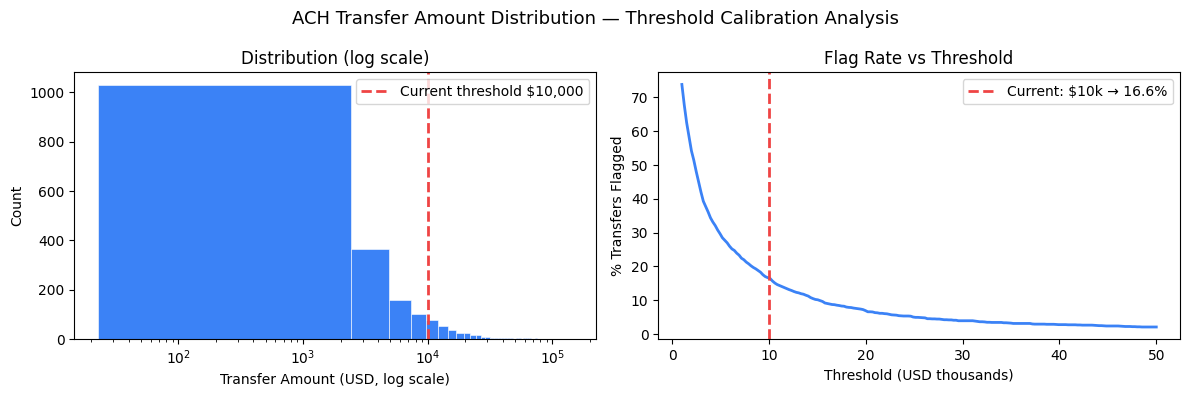

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('ACH Transfer Amount Distribution — Threshold Calibration Analysis', fontsize=13)

axes[0].hist(df['amount'], bins=60, color='#3B82F6', edgecolor='white', linewidth=0.4)
axes[0].axvline(threshold, color='#EF4444', linewidth=2, linestyle='--', label=f'Current threshold ${threshold:,.0f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Transfer Amount (USD, log scale)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution (log scale)')
axes[0].legend()

thresholds = np.linspace(1000, 50_000, 200)
flag_rates = [(df['amount'] >= t).mean() * 100 for t in thresholds]
axes[1].plot(thresholds / 1000, flag_rates, color='#3B82F6', linewidth=2)
axes[1].axvline(threshold / 1000, color='#EF4444', linewidth=2, linestyle='--',
             label=f'Current: ${threshold/1000:.0f}k → {flag_rate:.1f}%')
axes[1].set_xlabel('Threshold (USD thousands)')
axes[1].set_ylabel('% Transfers Flagged')
axes[1].set_title('Flag Rate vs Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

## Threshold Calibration Recommendation

**Current threshold:** $10,000 (inclusive)
**Current flag rate:** 16.6% of transfer volume (332 of 2,000 transfers)

### Findings
- The $10,000 threshold sits at the **83th percentile** of transfer volume.
- At this rate, 16.6% of all transfers are flagged — potentially high for a fraud operations team to review manually.
- The 95th percentile is $24,993 and the 99th is $64,823.

### Recommendation
Consider raising the threshold to $24,993 (95th percentile) to reduce alert fatigue while still catching outliers.

> ⚠️ **Compliance note:** Routing numbers and account numbers were excluded from this analysis per data handling policy in CLAUDE.md.
